In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
def cal_mean_sem(v):
    _v = np.stack(v)
    m = np.mean(_v, axis=0)
    ci = 1.96*np.std(_v, axis=0)/ np.sqrt(_v.shape[0])    
    return ", ".join(["%.3f±%.4f" % (a,b) for a,b in zip(m, ci)])

In [3]:
data1 = pd.read_pickle('G_ripple_data1.pkl') ## winner and their control group
data1.head(2)## yearlymat_def: deflated yearly citations

,matched_group,type,publication_year,concept,teamsize,treated_year,treated_paper,yearlymat,yearlymat_def
1520250,1,journal-article,1967,Physics,3,NaN,False,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 1]","[1.7867700508844198, 1.7507122507122508, 1.762..."
1520268,1,journal-article,1967,Physics,3,1978.0,True,"[1, 1, 1, 1, 0, 1, 0, 0, 2, 0]","[1.7867700508844198, 1.7507122507122508, 1.762..."


In [4]:
data1.shape

(466368, 9)

In [5]:
treated_cit  = data1[(data1.treated_paper==True)] #winner
print("treated paper±95%CI: ", cal_mean_sem(treated_cit.yearlymat_def.values))

treated paper±95%CI:  0.655±0.0126, 0.691±0.0132, 0.752±0.0138, 0.836±0.0145, 1.001±0.0158, 1.203±0.0187, 1.199±0.0203, 1.125±0.0212, 1.044±0.0229, 0.956±0.0190


In [6]:
matched_cit  = data1[(data1.treated_paper==False)]
print ("matched paper±95%CI:", cal_mean_sem(matched_cit.yearlymat_def.values))

matched paper±95%CI: 0.635±0.0117, 0.670±0.0124, 0.727±0.0126, 0.816±0.0128, 0.977±0.0149, 0.969±0.0156, 0.925±0.0147, 0.847±0.0137, 0.783±0.0135, 0.714±0.0125


In [7]:
time_to_prize = np.arange(-5, 5)
treated_effect = [0.655, 0.691, 0.752, 0.836, 1.001, 1.203, 1.199, 1.125, 1.044, 0.956]
matched_effect = [0.635, 0.670, 0.727, 0.816, 0.977, 0.969, 0.925, 0.847, 0.783, 0.714]
treated_ci = [0.0126, 0.0132, 0.0138, 0.0145, 0.0158, 0.0187, 0.0203, 0.0212, 0.0229, 0.0190]
matched_ci = [0.0117, 0.0124, 0.0126, 0.0128, 0.0149, 0.0156, 0.0147, 0.0137, 0.0135, 0.0125]

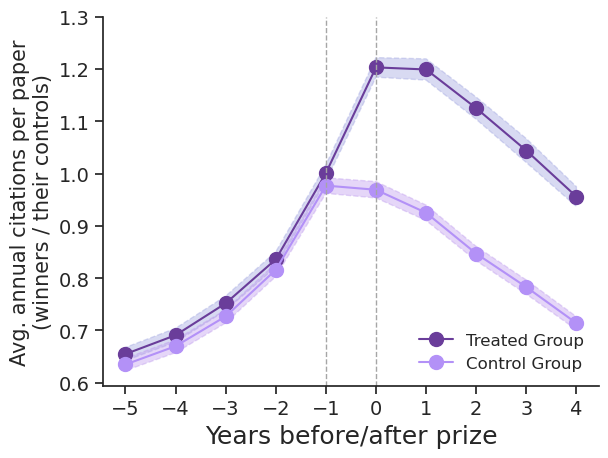

In [8]:
sns.set(font_scale=1.5)
sns.set(style="ticks")

plt.plot(time_to_prize, treated_effect, '-o', label='Treated Group', color='#6A3D9A', markersize=10) 
plt.plot(time_to_prize, matched_effect, '-o', label='Control Group', color='#B391F7', markersize=10)
plt.fill_between(time_to_prize, np.array(treated_effect) - np.array(treated_ci), np.array(treated_effect) + np.array(treated_ci), alpha=0.4, color='#9EA3E0',linestyle='dashed')
plt.fill_between(time_to_prize, np.array(matched_effect) - np.array(matched_ci), np.array(matched_effect) + np.array(matched_ci), alpha=0.4, color='#BE9AEE',linestyle='dashed')
plt.axvline(x=0, linestyle='--', color='#A6A6A6', linewidth=1)
plt.axvline(x=-1, linestyle='--', color='#A6A6A6', linewidth=1)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0),fontsize=12,frameon=False)
plt.xlabel('Years before/after prize',fontsize=18)
plt.ylabel(r'Avg. annual citations per paper' + '\n' +
           r'(winners / their controls)', fontsize=15)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(np.arange(-5, 5, 1),fontsize=14)
plt.yticks(np.arange(0.6, 1.4, 0.1),fontsize=14)
plt.show()

In [10]:
data2 = pd.read_pickle('G_ripple_data2.pkl') ## coauthor and their control group
data2.head(2)

,matched_group,type,publication_year,concept,teamsize,treated_year,treated_paper,yearlymat,yearlymat_def
71375336,1,journal-article,2011,Medicine,3,NaN,False,"[7, 1, 0, 1, 0, 0, 0, 0, 0, 0]","[2.278916660198194, 0.31588335270592904, 0.0, ..."
71375356,1,journal-article,2011,Medicine,3,2017.0,True,"[7, 1, 0, 1, 0, 3, 0, 1, 0, 0]","[2.278916660198194, 0.31588335270592904, 0.0, ..."


In [11]:
treated_cit  = data2[(data2.treated_paper==True)] 
print("treated paper±95%CI: ", cal_mean_sem(treated_cit.yearlymat_def.values))

treated paper±95%CI:  0.397±0.0017, 0.468±0.0017, 0.568±0.0019, 0.699±0.0020, 0.865±0.0022, 1.026±0.0026, 1.022±0.0027, 0.960±0.0027, 0.896±0.0027, 0.822±0.0027


In [12]:
matched_cit  = data2[(data2.treated_paper==False)]
print ("matched paper±95%CI:", cal_mean_sem(matched_cit.yearlymat_def.values) )

matched paper±95%CI: 0.394±0.0017, 0.466±0.0017, 0.566±0.0018, 0.697±0.0020, 0.863±0.0022, 0.939±0.0025, 0.920±0.0025, 0.865±0.0025, 0.807±0.0025, 0.742±0.0024


In [13]:
time_to_prize = np.arange(-5, 5)
treated_effect = [0.397, 0.468, 0.568, 0.699, 0.865, 1.026, 1.022, 0.960, 0.896, 0.822]
matched_effect = [0.394, 0.466, 0.566, 0.697, 0.863, 0.939, 0.920, 0.865, 0.807, 0.742]
treated_ci = [0.0017, 0.0017, 0.0019, 0.0020, 0.0022, 0.0026, 0.0027, 0.0027, 0.0027, 0.0027]
matched_ci = [0.0017, 0.0017, 0.0018, 0.0020, 0.0022, 0.0025, 0.0025, 0.0025, 0.0025, 0.0024]

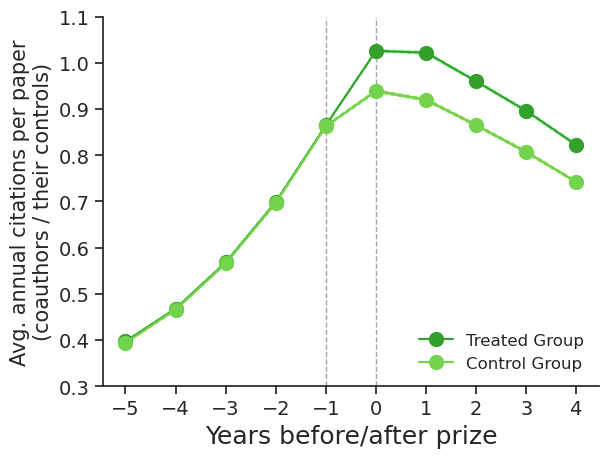

In [14]:
sns.set(font_scale=1.5)
sns.set(style="ticks")

plt.plot(time_to_prize, treated_effect, '-o', label='Treated Group', color='#33A02C',markersize=10) 
plt.plot(time_to_prize, matched_effect, '-o', label='Control Group', color='#73D34D',markersize=10)
plt.fill_between(time_to_prize, np.array(treated_effect) - np.array(treated_ci), np.array(treated_effect) + np.array(treated_ci), alpha=1, color='#85F78D',linestyle='dashed')
plt.fill_between(time_to_prize, np.array(matched_effect) - np.array(matched_ci), np.array(matched_effect) + np.array(matched_ci), alpha=1, color='#90D64A',linestyle='dashed')
plt.axvline(x=0, linestyle='--', color='#A6A6A6', linewidth=1,zorder=1)
plt.axvline(x=-1, linestyle='--', color='#A6A6A6', linewidth=1,zorder=1)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0),fontsize=12,frameon=False)
plt.xlabel('Years before/after prize',fontsize=18)
plt.ylabel(r'Avg. annual citations per paper'+ '\n' +
           r'(coauthors / their controls)', fontsize=15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(np.arange(-5, 5, 1),fontsize=14)
plt.yticks(np.arange(0.3, 1.2, 0.1),fontsize=14)
plt.show()